# Pyomo Infeasibility Debug

Focused reproduction of the first failing Electricity & E-Cooking optimization trial. This notebook keeps only inputs, model construction/solve, and optimization diagnostics.

In [59]:
from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint,
    NonNegativeReals, Reals, Binary, minimize, SolverFactory,
    TerminationCondition, value
)

N_PERIODS = 12
YEARS = list(range(2023, 2035))

# Exact first failing Electricity & E-Cooking inputs from main_pipeline.ipynb.
TECHNO_ELEC = {
    'GRID': {
        'Demand': [1473.6, 1616.8, 1793.2, 1954.5, 2101.6, 2235.1, 2355.9, 2518.5, 2659.5, 2786.4, 2900, 3001],
        'CAPEX - Growth': [257.3, 324.6, 321.4, 318.2, 315, 311.8, 382, 451.1, 446.6, 442.1, 437.7, 290.8],
        'OPEX': [48.2, 54.6, 62.2, 69.6, 77, 84.1, 91.1, 102.2, 112.7, 123, 133.1, 143],
    },
    'OFF-GRID': {
        'Demand': [368.4, 379.3, 393.6, 400.3, 400.3, 394.4, 383.5, 376.3, 362.7, 344.4, 322.2, 296.8],
        'CAPEX - Growth': [39.5, 50.3, 49.8, 49.3, 48.8, 48.4, 15.4, -17.1, -16.9, -16.8, -16.6, -1.7],
        'OPEX': [56.1, 64.7, 74.9, 84.8, 94.5, 104, 113.4, 111.6, 105.1, 98.8, 92.6, 86.4],
    },
}
TARIFFS = [0.15, 0.16, 0.17, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.26]
NTLOSSES = {t: 0.05 for t in range(N_PERIODS)}
DAYS_RECEIVABLE = {t: 30.0 for t in range(N_PERIODS)}
DAYS_PAYABLE = {t: 30.0 for t in range(N_PERIODS)}
COST_UPSTREAM = {t: 0.0 for t in range(N_PERIODS)}
TAX_RATE = 0.28

# Parameters recorded for the failing Optuna trial 0.
PCT_EQUITY = 0.2
PCT_DEBT = 1 - PCT_EQUITY
PCT_GRANTS = 0.13
COST_EQUITY = 0.16
COST_DEBT = 0.08
YEARS_REALISATION = 8
GRACE_PERIOD = 6
AMORTIZATION_PERIOD = 25

print('Input dimensions:', len(YEARS), 'periods')
print('Trial parameters:', {'pct_debt': PCT_DEBT, 'pct_grants': PCT_GRANTS, 'grace_period': GRACE_PERIOD, 'amortization_period': AMORTIZATION_PERIOD})

Input dimensions: 12 periods
Trial parameters: {'pct_debt': 0.8, 'pct_grants': 0.13, 'grace_period': 6, 'amortization_period': 25}


In [60]:
# Reproduce make_capex_data and make_k1_k2 locally.
def make_capex_data(tech_dict, n_periods):
    return sum(
        tech_dict.get('GRID', {}).get('CAPEX - Growth', [])[t]
        if t < len(tech_dict.get('GRID', {}).get('CAPEX - Growth', [])) else 0
        for t in range(n_periods)
    ) + sum(
        tech_dict.get('OFF-GRID', {}).get('CAPEX - Growth', [])[t]
        if t < len(tech_dict.get('OFF-GRID', {}).get('CAPEX - Growth', [])) else 0
        for t in range(n_periods)
    )


def make_k1_k2(tech_dict, n_periods):
    capex = [sum(tech_dict.get(system, {}).get('CAPEX - Growth', [0] * n_periods)[t]
                 if t < len(tech_dict.get(system, {}).get('CAPEX - Growth', [])) else 0
                 for system in ('GRID', 'OFF-GRID')) for t in range(n_periods)]
    capex_cum = []
    total = 0.0
    for amount in capex:
        total += amount
        capex_cum.append(total)
    demand = [sum(tech_dict.get(system, {}).get('Demand', [0] * n_periods)[t]
                  if t < len(tech_dict.get(system, {}).get('Demand', [])) else 0
                  for system in ('GRID', 'OFF-GRID')) for t in range(n_periods)]
    opex = [sum(tech_dict.get(system, {}).get('OPEX', [0] * n_periods)[t]
                if t < len(tech_dict.get(system, {}).get('OPEX', [])) else 0
                for system in ('GRID', 'OFF-GRID')) for t in range(n_periods)]
    mean_capex = sum(capex_cum) / len(capex_cum)
    mean_demand = sum(demand) / len(demand)
    denominator_k1 = sum((amount - mean_capex) ** 2 for amount in capex_cum)
    k1 = sum((amount - mean_capex) * (demand_value - mean_demand)
             for amount, demand_value in zip(capex_cum, demand)) / denominator_k1
    demand_base = mean_demand - k1 * mean_capex
    denominator_k2 = sum(demand_value ** 2 for demand_value in demand)
    k2 = sum(demand_value * opex_value for demand_value, opex_value in zip(demand, opex)) / denominator_k2
    return demand_base, k1, k2

CAPEX_TOTAL = make_capex_data(TECHNO_ELEC, N_PERIODS)
DEMAND_BASE, K1, K2 = make_k1_k2(TECHNO_ELEC, N_PERIODS)
print({'capex_total': CAPEX_TOTAL, 'demand_base': DEMAND_BASE, 'K1': K1, 'K2': K2})
assert len(TARIFFS) == N_PERIODS
assert all(len(TECHNO_ELEC[system][key]) == N_PERIODS for system in TECHNO_ELEC for key in ('Demand', 'CAPEX - Growth', 'OPEX'))

{'capex_total': 4531.0, 'demand_base': 1833.3623111678614, 'K1': 0.34069764814019626, 'K2': 0.0693781660993372}


In [115]:
# Full standalone copy of build_model from pyomo_model.py.
def build_debug_model():
    model = ConcreteModel()
    model.T = Set(initialize=range(N_PERIODS), ordered=True)
    model.capex_total = Param(initialize=CAPEX_TOTAL, mutable=True)
    model.cost_upstream_data = Param(model.T, initialize=COST_UPSTREAM, mutable=True)
    model.demand_base = Param(initialize=DEMAND_BASE, mutable=True)
    model.K1 = Param(initialize=K1, mutable=True)
    model.K2 = Param(initialize=K2, mutable=True)
    model.tariffs = Param(model.T, initialize={t: TARIFFS[t] for t in range(N_PERIODS)}, mutable=True)
    model.NTLOSSES = Param(model.T, initialize=NTLOSSES, mutable=True)
    model.DAYS_PAYABLE = Param(model.T, initialize=DAYS_PAYABLE, mutable=True)
    model.DAYS_RECEIVABLE = Param(model.T, initialize=DAYS_RECEIVABLE, mutable=True)
    model.TAXRATE = Param(initialize=TAX_RATE, mutable=True)
    model.pct_grants = Param(initialize=PCT_GRANTS, mutable=True)
    model.N_DEPREC = Param(initialize=35, mutable=True)
    model.T1 = Param(initialize=GRACE_PERIOD, mutable=True)
    model.T2 = Param(initialize=AMORTIZATION_PERIOD, mutable=True)
    model.COST_OF_DEBT = Param(initialize=COST_DEBT, mutable=True)
    model.WACC = Param(initialize=COST_EQUITY * PCT_EQUITY + COST_DEBT * PCT_DEBT, mutable=True)

    model.tariff_income = Var(model.T, within=NonNegativeReals)
    model.grants = Var(model.T, within=NonNegativeReals)
    model.lt_subsidies = Var(model.T, within=NonNegativeReals)
    model.service_margin = Var(model.T, within=NonNegativeReals)
    model.sub_or_mar = Var(model.T, within=Binary)
    model.revenues = Var(model.T, within=Reals)
    model.upstream = Var(model.T, within=NonNegativeReals)
    model.opex = Var(model.T, within=NonNegativeReals)
    model.provisions = Var(model.T, within=NonNegativeReals)
    model.costs = Var(model.T, within=NonNegativeReals)
    model.capex_data = Var(model.T, within=NonNegativeReals)
    model.rab = Var(model.T, within=NonNegativeReals)
    model.wc = Var(model.T, within=Reals)
    model.dwc = Var(model.T, within=Reals)
    model.treceivables = Var(model.T, within=NonNegativeReals)
    model.tpayables = Var(model.T, within=NonNegativeReals)
    model.da = Var(model.T, within=NonNegativeReals)
    model.taxes = Var(model.T, within=NonNegativeReals)
    model.acofservice = Var(model.T, within=NonNegativeReals)
    model.ebitda = Var(model.T, within=Reals)
    model.ebit = Var(model.T, within=Reals)
    model.ebt = Var(model.T, within=Reals)
    model.ebt_cum = Var(model.T, within=Reals)
    model.cum = Var(model.T, within=NonNegativeReals)
    model.profit = Var(model.T, within=NonNegativeReals)
    model.loss = Var(model.T, within=NonNegativeReals)
    model.loss_used = Var(model.T, within=NonNegativeReals)
    model.p_or_l = Var(model.T, within=Binary)
    model.tax_or_cum = Var(model.T, within=Binary)
    model.taxable = Var(model.T, within=NonNegativeReals)
    model.financial_expenses = Var(model.T, within=NonNegativeReals)
    model.cash_flow = Var(model.T, within=Reals)
    model.equity = Var(model.T, within=NonNegativeReals)
    model.debt = Var(model.T, within=NonNegativeReals)
    model.repay = Var(model.T, within=NonNegativeReals)

    model.obj = Objective(rule=lambda m: sum(m.debt[t] for t in m.T), sense=minimize)

    def revenue_rule(m, t):
        return m.tariff_income[t] + m.grants[t] + m.lt_subsidies[t] == m.revenues[t]
    model.c_revenues = Constraint(model.T, rule=revenue_rule)

    def tariff_income_rule(m, t):
        accumulated_capex = sum(m.capex_data[tt] for tt in m.T if tt <= t)
        return m.tariff_income[t] == m.tariffs[t] * (m.demand_base + m.K1 * accumulated_capex)
    model.c_tariff_income = Constraint(model.T, rule=tariff_income_rule)

    def grants_rule(m, t):
        return m.grants[t] == m.pct_grants * m.capex_data[t] if t == 0 or t < YEARS_REALISATION else m.grants[t] == 0
    model.c_grants = Constraint(model.T, rule=grants_rule)
    model.c_lt_subsidies = Constraint(model.T, rule=lambda m, t: m.lt_subsidies[t] <= m.acofservice[t] - m.tariff_income[t] + m.service_margin[t])

    def sub_or_mar_1_rule(m, t):
        return m.lt_subsidies[t] <= 1e4 * m.sub_or_mar[t]
    model.c_sub_or_mar_1 = Constraint(model.T, rule=sub_or_mar_1_rule)

    def sub_or_mar_2_rule(m, t):
        return m.service_margin[t] <= 1e4 * (1 - m.sub_or_mar[t])
    model.c_sub_or_mar_2 = Constraint(model.T, rule=sub_or_mar_2_rule)

    model.c_costs = Constraint(model.T, rule=lambda m, t: m.upstream[t] + m.opex[t] + m.provisions[t] == m.costs[t])

    def upstream_rule(m, t):
        accumulated_capex = sum(m.capex_data[tt] for tt in m.T if tt <= t)
        return m.upstream[t] == m.cost_upstream_data[t] * (m.demand_base + m.K1 * accumulated_capex)
    model.c_upstream = Constraint(model.T, rule=upstream_rule)

    def opex_rule(m, t):
        accumulated_capex = sum(m.capex_data[tt] for tt in m.T if tt <= t)
        return m.opex[t] == m.K2 * (m.demand_base + m.K1 * accumulated_capex)
    model.c_opex = Constraint(model.T, rule=opex_rule)
    model.c_provisions = Constraint(model.T, rule=lambda m, t: m.provisions[t] == m.NTLOSSES[t] * m.K1 * m.capex_data[t])
    model.c_acofservice = Constraint(model.T, rule=lambda m, t: m.acofservice[t] == m.WACC * m.rab[t] + m.upstream[t] + m.opex[t] + m.provisions[t] + m.dwc[t] + m.da[t] + m.taxes[t])

    def rab_rule(m, t):
           return m.rab[t] == m.capex_data[t] - m.da[t] if t == 0 else m.rab[t] == m.capex_data[t] - m.da[t] + m.rab[t - 1]
    model.c_rab = Constraint(model.T, rule=rab_rule)

    def dwc_rule(m, t):
        return m.dwc[t] == 0 if t == 0 else m.dwc[t] == m.wc[t] - m.wc[t - 1]
    model.c_dwc = Constraint(model.T, rule=dwc_rule)
    model.c_wc = Constraint(model.T, rule=lambda m, t: m.wc[t] == m.treceivables[t] - m.tpayables[t])
    model.c_treceivables = Constraint(model.T, rule=lambda m, t: m.treceivables[t] == m.tariff_income[t] * m.DAYS_RECEIVABLE[t] / 365)
    model.c_tpayables = Constraint(model.T, rule=lambda m, t: m.tpayables[t] == (m.opex[t] + m.upstream[t]) * m.DAYS_PAYABLE[t] / 365)

    model.c_ebitda = Constraint(model.T, rule=lambda m, t: m.ebitda[t] == m.revenues[t] - m.costs[t])

    model.c_da = Constraint(model.T, rule=lambda m, t: m.da[t] == (1 / m.N_DEPREC) * sum(m.capex_data[s] for s in m.T if s <= t))
    model.c_ebit = Constraint(model.T, rule=lambda m, t: m.ebit[t] == m.ebitda[t] - m.da[t])

    model.c_financial_expenses = Constraint(model.T, rule=lambda m, t: m.financial_expenses[t] == sum(m.debt[s] - m.repay[s] for s in m.T if s <= t) * m.COST_OF_DEBT)
    model.c_ebt = Constraint(model.T, rule=lambda m, t: m.ebt[t] == m.ebit[t] - m.financial_expenses[t])

    def ebt_cum_rule(m, t):
        return m.ebt_cum[t] == m.ebt[t] - m.grants[t] - m.lt_subsidies[t]
    model.c_ebt_cum = Constraint(model.T, rule=ebt_cum_rule)

    def ebt_split_rule(m, t):
        return m.ebt_cum[t] == m.profit[t] - m.loss[t]
    model.c_ebt_split = Constraint(model.T, rule=ebt_split_rule)

    def profit_loss_1_rule(m, t):
        return m.profit[t] <= 1e4 * m.p_or_l[t]
    model.c_profit_loss_1 = Constraint(model.T, rule=profit_loss_1_rule)

    def profit_loss_2_rule(m, t):
        return m.loss[t] <= 1e4 * (1 - m.p_or_l[t])
    model.c_profit_loss_2 = Constraint(model.T, rule=profit_loss_2_rule)

    def cum_rule(m, t):
        return m.cum[t] == m.loss[t] - m.loss_used[t] if t == 0 else m.cum[t] == m.cum[t - 1] + m.loss[t] - m.loss_used[t]
    model.c_cum = Constraint(model.T, rule=cum_rule)

    def taxable_rule(m, t):
        return m.taxable[t] == m.profit[t] - m.loss_used[t]
    model.c_taxable = Constraint(model.T, rule=taxable_rule)

    def tax_or_cum__1_rule(m, t):
        return m.taxable[t] <= 1e4 * m.tax_or_cum[t]
    model.c_tax_or_cum_1 = Constraint(model.T, rule=tax_or_cum__1_rule)

    def tax_or_cum__2_rule(m, t):
        return m.cum[t] <= 1e4 * (1 - m.tax_or_cum[t])
    model.c_tax_or_cum_2 = Constraint(model.T, rule=tax_or_cum__2_rule)

    def taxes_rule(m, t):
        return m.taxes[t] == m.taxable[t] * m.TAXRATE
    model.c_taxes = Constraint(model.T, rule=taxes_rule)

    model.c_cash_flow = Constraint(model.T, rule=lambda m, t: m.cash_flow[t] == m.ebitda[t] - m.taxes[t] - m.dwc[t] - m.capex_data[t] - m.financial_expenses[t] - m.repay[t] + m.equity[t] + m.debt[t])
    model.c_debt = Constraint(model.T, rule=lambda m, t: m.debt[t] >= -m.cash_flow[t])

    def repay_rule(m, t):
        if t < GRACE_PERIOD:
            return m.repay[t] == 0
        return m.repay[t] == (1 / m.T2) * sum(m.debt[s] - m.repay[s] for s in m.T if s <= t - GRACE_PERIOD)
    model.c_repay = Constraint(model.T, rule=repay_rule)

    def equity_rule(m, t):
        return m.equity[t] == (PCT_EQUITY * sum(m.debt[s] for s in m.T))/PCT_DEBT if t == 0 else m.equity[t] == 0
    model.c_equity = Constraint(model.T, rule=equity_rule)

    model.c_capex_total = Constraint(rule=lambda m: sum(m.capex_data[t] for t in m.T) == m.capex_total)
    return model

model = build_debug_model()
print('Model built:', len(list(model.component_data_objects(Var))), 'variables and', len(list(model.component_data_objects(Constraint))), 'constraints')

Model built: 420 variables and 409 constraints


In [116]:
# Solve with Gurobi without loading a solution: this preserves infeasible termination metadata.
solver = SolverFactory('gurobi')
solver.options['OutputFlag'] = 0

if not solver.available(exception_flag=False):
    raise RuntimeError('The Gurobi solver is unavailable or its license is not visible to this Python environment')

solve_result = solver.solve(model, load_solutions=False)
termination = solve_result.solver.termination_condition
solver_status = solve_result.solver.status
if termination in {TerminationCondition.optimal, TerminationCondition.feasible}:
    solver.solve(model)
print('Solver status:', solver_status)
print('Termination condition:', termination)
print('Solver message:', getattr(solve_result.solver, 'message', None))
print('Has feasible solution:', termination in {TerminationCondition.optimal, TerminationCondition.feasible})

Solver status: ok
Termination condition: optimal
Solver message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
Has feasible solution: True


In [76]:
# Report outputs and residuals. Uninitialized variables are reported as None.
def safe_value(expression):
    try:
        return value(expression, exception=False)
    except (TypeError, ValueError):
        return None

print('\nConstraint diagnostics')
violations = []
for constraint in model.component_data_objects(Constraint, active=True):
    body = safe_value(constraint.body)
    lower = safe_value(constraint.lower)
    upper = safe_value(constraint.upper)
    residual = None
    if body is not None:
        if lower is not None and body < lower:
            residual = body - lower
        elif upper is not None and body > upper:
            residual = body - upper
        else:
            residual = 0.0
    if residual is None or abs(residual) > 1e-7:
        violations.append((constraint.name, body, lower, upper, residual))

for item in violations:
    print(item)
print('Potentially violated or unevaluable constraints:', len(violations))

if termination in {TerminationCondition.optimal, TerminationCondition.feasible}:
    print('\nKey solution schedules')
    for variable_name in ('capex_data', 'debt', 'lt_subsidies', 'cash_flow', 'tariff_income'):
        variable = getattr(model, variable_name)
        print(variable_name, [safe_value(variable[t]) for t in model.T])
    print('Objective:', safe_value(model.obj))
else:
    print('\nNo feasible solution was loaded; variable schedules are intentionally omitted.')


Constraint diagnostics
Potentially violated or unevaluable constraints: 0

Key solution schedules
capex_data [1284.9712179158062, 168.17070701161978, 190.64854310881995, 210.701679391395, 244.0629149736218, 276.7721836264669, 291.98403943262286, 332.5022982141346, 321.9702055165732, 358.65684087279965, 399.427416802445, 451.13195313369545]
debt [441.4074927639682, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
lt_subsidies [278.8558378082489, 251.18453097986367, 241.14545165403814, 253.56737447935285, 247.12120781224064, 239.03083680249665, 229.13708971277262, 219.99149903114485, 14.113554913555092, 11.538543386579292, 9.255069998231647, 131.86202232760243]
cash_flow [-441.40749276396815, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
tariff_income [340.672347455943, 372.5510955847285, 406.8776358027241, 419.0811821294566, 458.7003153757214, 502.0998363160392, 548.4217985964016, 599.6322662368024, 652.3189718706075, 710.0743489285553, 773.6073022698113, 878.03647227168

In [77]:
# Gurobi IIS / conflict refiner and diagnostic snapshot.
from pathlib import Path
import json
import shutil
import subprocess
from pyomo.opt import ProblemFormat

snapshot = {
    'termination_condition': str(termination),
    'solver_status': str(solver_status),
    'objective': safe_value(model.obj),
    'violations': [
        {'constraint': name, 'body': body, 'lower': lower, 'upper': upper, 'residual': residual}
        for name, body, lower, upper, residual in violations
    ],
}

# Export the exact Pyomo model, then let the licensed Gurobi CLI compute the IIS when needed.
lp_path = Path.cwd() / 'pyomo_infeasibility_debug.lp'
iis_path = Path.cwd() / 'pyomo_infeasibility_debug.ilp'
model.write(str(lp_path), format=ProblemFormat.cpxlp, io_options={'symbolic_solver_labels': True})
gurobi_cli = shutil.which('gurobi_cl')
iis_constraints = []

if termination == TerminationCondition.optimal:
    print('Model is feasible; IIS computation skipped.')
    if iis_path.exists():
        iis_path.unlink()
elif gurobi_cli is None:
    print('gurobi_cl was not found; IIS was not computed.')
else:
    iis_run = subprocess.run(
        [gurobi_cli, f'ResultFile={iis_path}', str(lp_path)],
        capture_output=True,
        text=True,
        check=False,
    )
    print(iis_run.stdout)
    if iis_run.returncode != 0:
        print(iis_run.stderr)
    elif iis_path.exists():
        iis_constraints = [
            line.strip()
            for line in iis_path.read_text(encoding='utf-8', errors='replace').splitlines()
            if line.strip() and not line.lstrip().startswith(('*', 'minimize', 'subject to', 'bounds', 'end'))
        ]
        print('IIS artifact written to:', iis_path)
        print('Review the artifact for the exact conflicting rows:', len(iis_constraints), 'non-header lines')

snapshot['iis_constraints'] = iis_constraints
snapshot['lp_path'] = str(lp_path)
snapshot['iis_path'] = str(iis_path) if iis_path.exists() else None
log_path = Path.cwd() / 'pyomo_infeasibility_debug_snapshot.json'
log_path.write_text(json.dumps(snapshot, indent=2, default=str), encoding='utf-8')
print('LP model written to:', lp_path)
print('Diagnostic snapshot written to:', log_path)

Model is feasible; IIS computation skipped.
LP model written to: c:\Users\pduen\Documents\GitHub\CC-WBT-AI\notebooks\pyomo_infeasibility_debug.lp
Diagnostic snapshot written to: c:\Users\pduen\Documents\GitHub\CC-WBT-AI\notebooks\pyomo_infeasibility_debug_snapshot.json


In [117]:
# Complete optimization output schedules.
OUTPUT_VARIABLES = {
    'tariff_income': 'tariff_income',
    'grants': 'grants',
    'lt_subsidies': 'lt_subsidies',
    'service_margin': 'service_margin',
    'revenues': 'revenues',
    'upstream_cost': 'upstream',
    'opex': 'opex',
    'provisions': 'provisions',
    'costs': 'costs',
    'acofservice': 'acofservice',
    'ebitda': 'ebitda',
    'da': 'da',
    'ebit': 'ebit',
    'financial_expenses': 'financial_expenses',
    'ebt': 'ebt',
    'ebt_cum': 'ebt_cum',
    'profit': 'profit',
    'loss': 'loss',
    'loss_used': 'loss_used',
    'p_or_l': 'p_or_l',
    'taxable': 'taxable',
    'taxes': 'taxes',
    'cum': 'cum',
    'cash_flow': 'cash_flow',
    'debt': 'debt',
    'repay': 'repay',
    'equity': 'equity',
    'capex_data': 'capex_data',
    'rab': 'rab',
    'wc': 'wc',
    'dwc': 'dwc',
    'treceivables': 'treceivables',
    'tpayables': 'tpayables',
}

if termination in {TerminationCondition.optimal, TerminationCondition.feasible}:
    output_schedules = {
        label: [safe_value(getattr(model, component_name)[t]) for t in model.T]
        for label, component_name in OUTPUT_VARIABLES.items()
    }
    print('\\nComplete optimization schedules')
    print(f"{'schedule':<22}" + ''.join(f'{year:>12}' for year in YEARS))
    for label, schedule in output_schedules.items():
        print(f"{label:<22}" + ''.join(f'{number:>12.3f}' if number is not None else f'{str(number):>12}' for number in schedule))
    print('\\nScalar outputs')
    print('WACC:', safe_value(model.WACC))
    print('Objective / total debt:', safe_value(model.obj))
else:
    print('No solution schedules available because the model is not feasible.')

\nComplete optimization schedules
schedule                      2023        2024        2025        2026        2027        2028        2029        2030        2031        2032        2033        2034
tariff_income              288.243     315.489     345.024     418.528     457.862     500.866     548.141     600.384     654.047     711.296     774.116     878.036
grants                      33.678      19.148      22.035     164.981      31.193      35.279      39.900      45.128       0.000       0.000       0.000       0.000
lt_subsidies                 0.000       0.000       0.000      37.084      21.668      21.121      21.498      22.824      19.686      16.124      13.065       0.000
service_margin           10000.000   10000.000   10000.000       0.000       0.000       0.000       0.000       0.000       0.000       0.000       0.000   10000.000
revenues                   321.921     334.637     367.060     620.593     510.723     557.265     609.539     668.337     673.733 

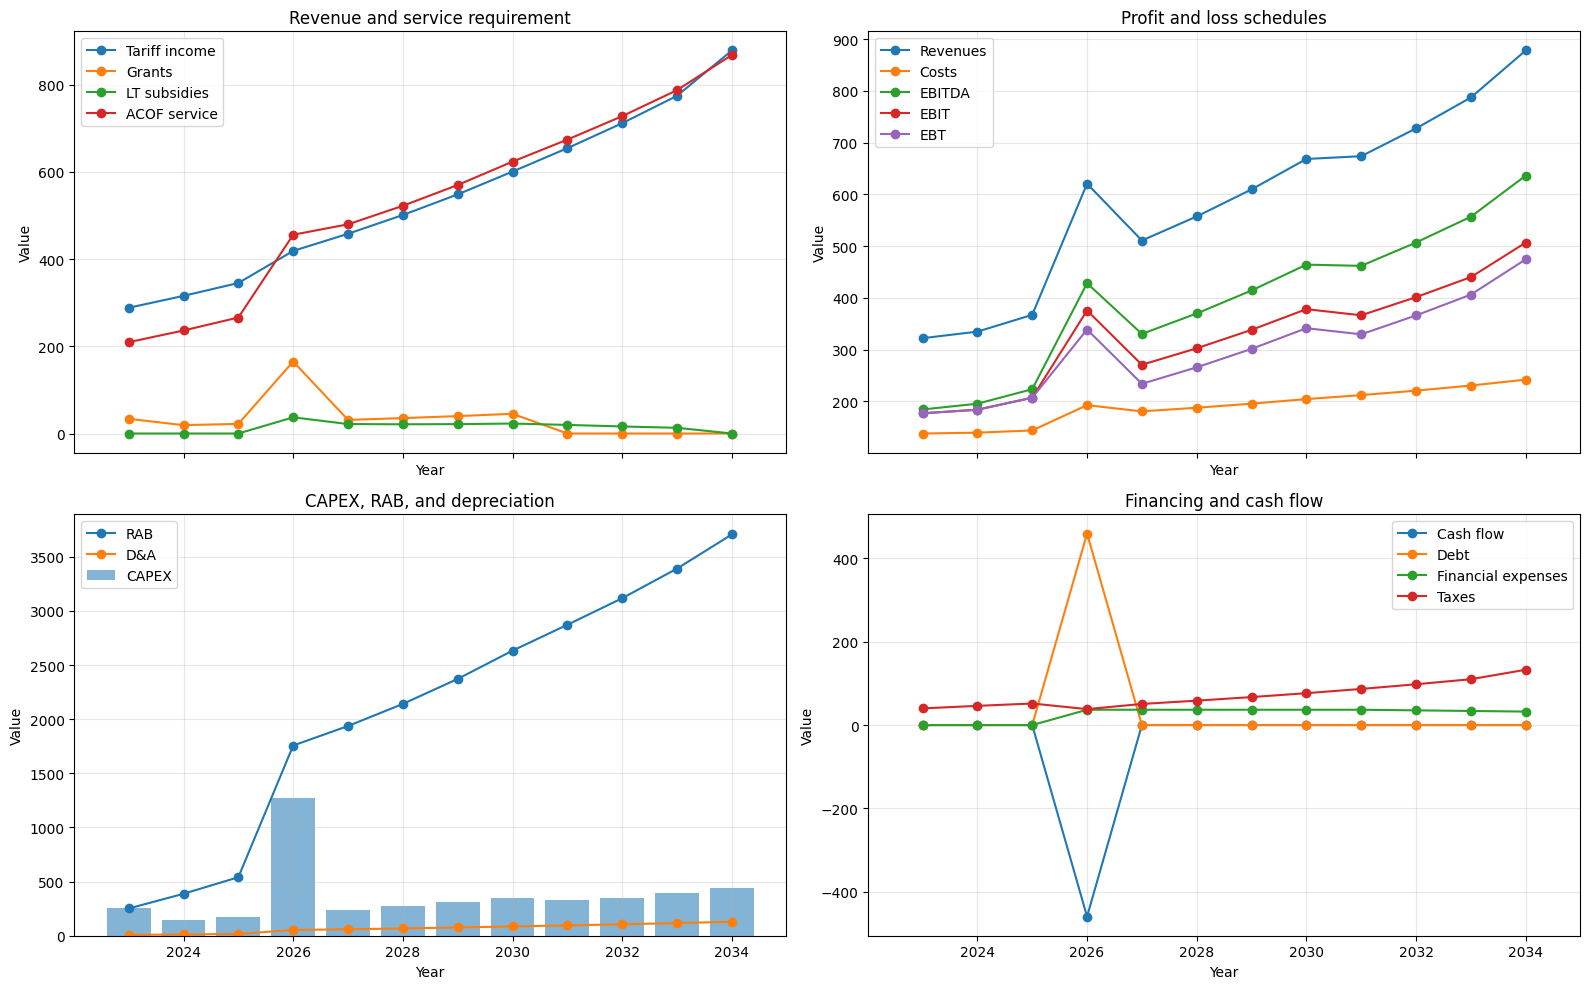

In [118]:
# Plot the main optimization schedules.
import matplotlib.pyplot as plt

if termination in {TerminationCondition.optimal, TerminationCondition.feasible}:
    figure, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
    years = YEARS

    axes[0, 0].plot(years, output_schedules['tariff_income'], marker='o', label='Tariff income')
    axes[0, 0].plot(years, output_schedules['grants'], marker='o', label='Grants')
    axes[0, 0].plot(years, output_schedules['lt_subsidies'], marker='o', label='LT subsidies')
    axes[0, 0].plot(years, output_schedules['acofservice'], marker='o', label='ACOF service')
    axes[0, 0].set_title('Revenue and service requirement')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].legend()

    axes[0, 1].plot(years, output_schedules['revenues'], marker='o', label='Revenues')
    axes[0, 1].plot(years, output_schedules['costs'], marker='o', label='Costs')
    axes[0, 1].plot(years, output_schedules['ebitda'], marker='o', label='EBITDA')
    axes[0, 1].plot(years, output_schedules['ebit'], marker='o', label='EBIT')
    axes[0, 1].plot(years, output_schedules['ebt'], marker='o', label='EBT')
    axes[0, 1].set_title('Profit and loss schedules')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].legend()

    axes[1, 0].bar(years, output_schedules['capex_data'], alpha=0.55, label='CAPEX')
    axes[1, 0].plot(years, output_schedules['rab'], marker='o', label='RAB')
    axes[1, 0].plot(years, output_schedules['da'], marker='o', label='D&A')
    axes[1, 0].set_title('CAPEX, RAB, and depreciation')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].legend()

    axes[1, 1].plot(years, output_schedules['cash_flow'], marker='o', label='Cash flow')
    axes[1, 1].plot(years, output_schedules['debt'], marker='o', label='Debt')
    axes[1, 1].plot(years, output_schedules['financial_expenses'], marker='o', label='Financial expenses')
    axes[1, 1].plot(years, output_schedules['taxes'], marker='o', label='Taxes')
    axes[1, 1].set_title('Financing and cash flow')
    axes[1, 1].set_ylabel('Value')
    axes[1, 1].legend()

    for axis in axes.flat:
        axis.grid(True, alpha=0.3)
        axis.set_xlabel('Year')
    figure.tight_layout()
    plt.show()
else:
    print('No plots available because the model is not feasible.')

In [120]:
# Export the complete optimization table to CSV.
import csv
from pathlib import Path

csv_path = Path.cwd() / 'pyomo_optimization_output.csv'
if termination in {TerminationCondition.optimal, TerminationCondition.feasible}:
    with csv_path.open('w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(['schedule', *YEARS])
        for label, schedule in output_schedules.items():
            writer.writerow([label, *schedule])
    print('Optimization table exported to:', csv_path)
else:
    print('CSV was not written because the model is not feasible.')

Optimization table exported to: c:\Users\pduen\Documents\GitHub\CC-WBT-AI\notebooks\pyomo_optimization_output.csv
